In [1]:
# notwendige Libraries laden.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from PIL import Image
import io
import os
import glob
import base64
import cv2

In [2]:
# MNIST Datensatz als CSV einlesen: die einzelnen Spalten entsprechen Pixeln.
# zu finden unter: 
# https://www.kaggle.com/datasets/oddrationale/mnist-in-csv

mnist = pd.read_csv('mnist_test.csv')
mnist.head(6)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Auswahl treffen: lediglich die Zahlen '2', '4' und '9' werden ausgewählt

class_128 = mnist[(mnist["label"] == 1) | (mnist["label"] == 2) | (mnist["label"] == 8)] # Auswählen
print(class_128.shape[0]) # Insgesamt-Anzahl an ausgewählten Zahlen bestimmen
auswahl = class_128.head(300) # die ersten 300 Datensätze auswählen und dem Objekt 'auswahl' zuweisen
auswahl = auswahl.reset_index(drop=True) # die Spalte '0' verwerfen, da sie keinerlei Information trägt
auswahl.to_csv('class_128_28x28.csv',index=False) # auswahl als CSV-Datei speichern

3141


Aufloesung in DPI: 100.0
label: 2 höhe: 28 breite: 28


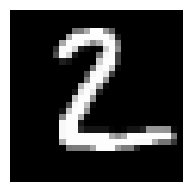

label: 1 höhe: 28 breite: 28


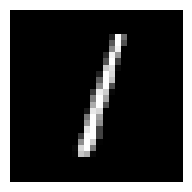

label: 1 höhe: 28 breite: 28


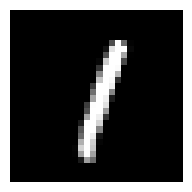

label: 1 höhe: 28 breite: 28


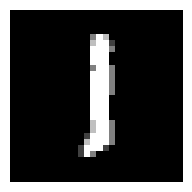

label: 1 höhe: 28 breite: 28


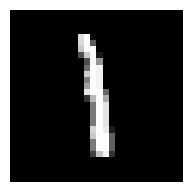

label: 1 höhe: 28 breite: 28


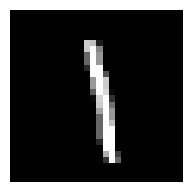

label: 2 höhe: 28 breite: 28


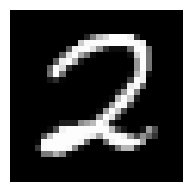

label: 1 höhe: 28 breite: 28


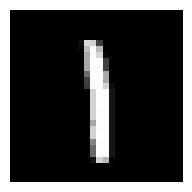

label: 2 höhe: 28 breite: 28


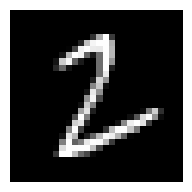

label: 1 höhe: 28 breite: 28


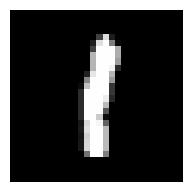

label: 1 höhe: 28 breite: 28


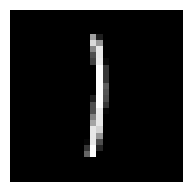

label: 2 höhe: 28 breite: 28


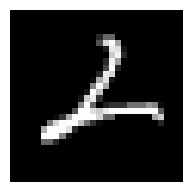

label: 1 höhe: 28 breite: 28


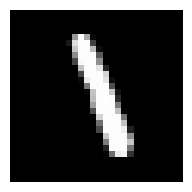

label: 2 höhe: 28 breite: 28


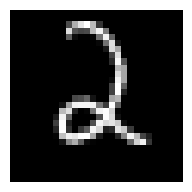

label: 1 höhe: 28 breite: 28


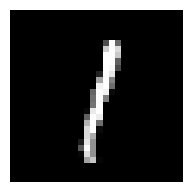

label: 8 höhe: 28 breite: 28


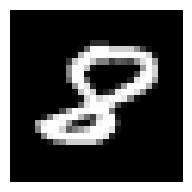

label: 2 höhe: 28 breite: 28


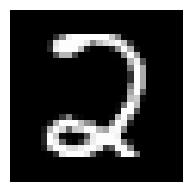

label: 1 höhe: 28 breite: 28


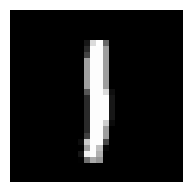

label: 2 höhe: 28 breite: 28


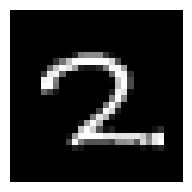

label: 2 höhe: 28 breite: 28


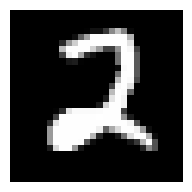

label: 8 höhe: 28 breite: 28


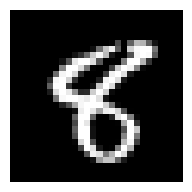

label: 1 höhe: 28 breite: 28


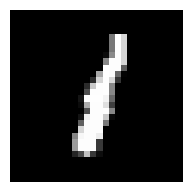

label: 1 höhe: 28 breite: 28


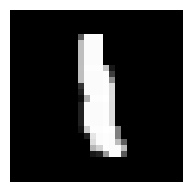

label: 1 höhe: 28 breite: 28


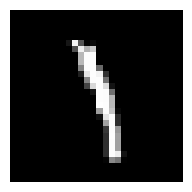

label: 2 höhe: 28 breite: 28


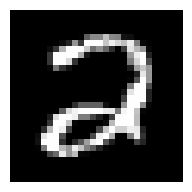

label: 1 höhe: 28 breite: 28


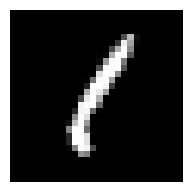

label: 8 höhe: 28 breite: 28


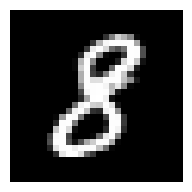

label: 2 höhe: 28 breite: 28


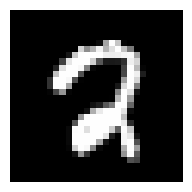

label: 8 höhe: 28 breite: 28


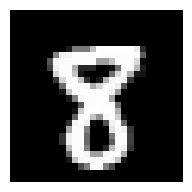

label: 8 höhe: 28 breite: 28


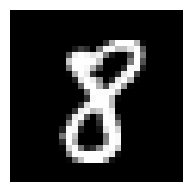

In [5]:
# einige Beispiel-Bilder darstellen, um sich einen Überblick zu verschaffen

dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

for i in range(0,30): # Testweise 10 Bilder darstellen
    testbild = auswahl.values[i,1:].reshape(28,28) # Umwandeln des 1D-Arrays in ein 28x28-Array
    testlabel = auswahl.values[i,0] # in Spalte '1' ist das Label, was hier ausgelesen wird
    
    h, w = testbild.shape # Dimension überprüfen
    print("label: " + str(testlabel) + " höhe: " + str(h), "breite: " + str(w)) #String für Bildbezeichnung bilden
    
    plt.figure(figsize=(8*w / float(dpi), 8*h / float(dpi))) # Größe entsprechend DPI-Auflösung
    plt.axis('off') # Achsendarstellung ausschalten
    plt.imshow(testbild, cmap='gray') # Als Graustufenbild darstellen
    plt.show() # Bild darstellen
    
    string = "mnist_"+str(testlabel)+"_"+str(i)+"_28x28.png"
    plt.imsave(string, testbild, cmap='gray')